# Individual Task 2
#  Data Analysis — Adult (Census Income) & Diabetes 130-US Hospitals
# Improvement based on Task 1 feedback
# Deliberation on Task 1
**Sarthak Shakya (s4238557), RMIT University**

Assignment: Part 2.2 — Improved Data Analysis and includes Fairness evalutation 

Two models are applied to two datasets: **Logistic Regression** and **SVM (linear kernel)**.
Both are new to this assignment (Decision Tree and k-NN were used in Practical Data Science, COSC2670).

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, classification_report)
import matplotlib.pyplot as plt
from fairlearn.metrics import MetricFrame, selection_rate

RANDOM_STATE = 42

# Adult Dataset

In [6]:
# loading and inspecting the adult dataset
cols = ["age","workclass","fnlwgt","education","education_num","marital_status",
        "occupation","relationship","race","sex","capital_gain","capital_loss",
        "hours_per_week","native_country","income"]

train = pd.read_csv("adult.data", names=cols, skipinitialspace=True, na_values="?")
test = pd.read_csv("adult.test", names=cols, skipinitialspace=True, na_values="?", skiprows=1)
test["income"] = test["income"].str.replace(".", "", regex=False)

adult = pd.concat([train, test], ignore_index=True)
print(f"Total records: {len(adult)}")
print(f"Missing values per column:\n{adult.isna().sum()[adult.isna().sum()>0]}")
print(f"\nClass balance:\n{adult['income'].value_counts(normalize=True)}")

Total records: 48842
Missing values per column:
workclass         2799
occupation        2809
native_country     857
dtype: int64

Class balance:
income
<=50K    0.760718
>50K     0.239282
Name: proportion, dtype: float64


In [7]:
# Data cleaning and preserving the race/sex for future fairness check
n_before = len(adult)
adult_clean = adult.dropna()
print(f"Dropped {n_before - len(adult_clean)} rows with missing values ({(n_before-len(adult_clean))/n_before*100:.1f}%)")

# keep race/sex aside before encoding, needed later for the fairness check
race_sex = adult_clean[["race", "sex"]].reset_index(drop=True)

y = (adult_clean["income"] == ">50K").astype(int)
X = adult_clean.drop(columns=["income"])

Dropped 3620 rows with missing values (7.4%)


In [8]:
# encoding the catagorical data
cat_cols = X.select_dtypes(include="object").columns
le_dict = {}
for c in cat_cols:
    le = LabelEncoder()
    X[c] = le.fit_transform(X[c])
    le_dict[c] = le

In [10]:
# splitting into train/test set
X_train, X_test, y_train, y_test, rs_train, rs_test = train_test_split(
    X, y, race_sex, test_size=0.3, random_state=RANDOM_STATE, stratify=y)

# scaling the dataset
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [11]:
# trainning the model --- baseline
results_adult = {}

lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train_s, y_train)
pred_lr = lr.predict(X_test_s)
proba_lr = lr.predict_proba(X_test_s)[:, 1]
results_adult["Logistic Regression"] = {
    "accuracy": accuracy_score(y_test, pred_lr),
    "precision": precision_score(y_test, pred_lr),
    "recall": recall_score(y_test, pred_lr),
    "f1": f1_score(y_test, pred_lr),
    "roc_auc": roc_auc_score(y_test, proba_lr)
}

sample_idx = X_train.sample(n=8000, random_state=RANDOM_STATE).index
X_train_svm = scaler.transform(X_train.loc[sample_idx])
y_train_svm = y_train.loc[sample_idx]

svm_model = LinearSVC(random_state=RANDOM_STATE, max_iter=5000)
svm_model.fit(X_train_svm, y_train_svm)
pred_svm = svm_model.predict(X_test_s)

results_adult["SVM"] = {
    "accuracy": accuracy_score(y_test, pred_svm),
    "precision": precision_score(y_test, pred_svm),
    "recall": recall_score(y_test, pred_svm),
    "f1": f1_score(y_test, pred_svm)
}
svm_scores = svm_model.decision_function(X_test_s)
results_adult["SVM"]["roc_auc"] = roc_auc_score(y_test, svm_scores)

pd.DataFrame(results_adult).T

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.818235,0.709738,0.450922,0.551473,0.848068
SVM,0.817793,0.723394,0.428614,0.538289,0.847347


In [12]:
# using 5 fold cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = cross_validate(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    X_train_s, y_train,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"]
)

print("5-fold Cross-Validation Results (Logistic Regression, Adult dataset)")
for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    scores = cv_results[f"test_{metric}"]
    print(f"{metric}: {scores.mean():.3f} ± {scores.std():.3f}")

5-fold Cross-Validation Results (Logistic Regression, Adult dataset)
accuracy: 0.821 ± 0.005
precision: 0.718 ± 0.012
recall: 0.459 ± 0.013
f1: 0.560 ± 0.013
roc_auc: 0.852 ± 0.006


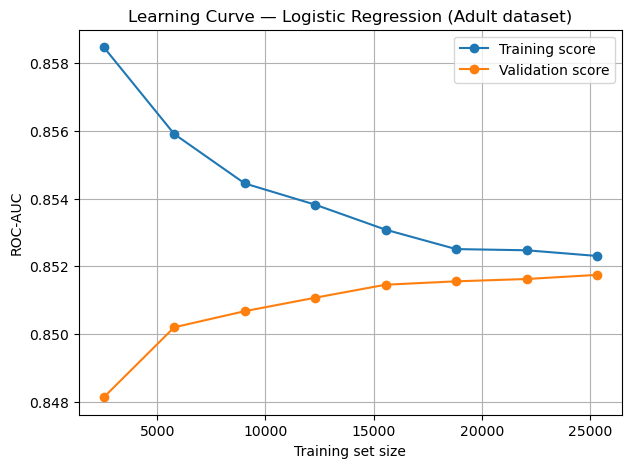

In [13]:
# creating a learning curve
train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    X_train_s, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=5,
    scoring="roc_auc",
    random_state=RANDOM_STATE
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(7, 5))
plt.plot(train_sizes, train_mean, "o-", label="Training score")
plt.plot(train_sizes, val_mean, "o-", label="Validation score")
plt.xlabel("Training set size")
plt.ylabel("ROC-AUC")
plt.title("Learning Curve — Logistic Regression (Adult dataset)")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
# including a fairness check for sex using the fairlearn library
metric_frame_sex = MetricFrame(
    metrics={"recall": recall_score, "selection_rate": selection_rate},
    y_true=y_test, y_pred=pred_lr,
    sensitive_features=rs_test["sex"]
)
print("Fairlearn metrics by sex:")
print(metric_frame_sex.by_group)
print(f"Recall difference (max - min): {metric_frame_sex.difference()['recall']:.3f}")

Fairlearn metrics by sex:
          recall  selection_rate
sex                             
Female  0.194118        0.033713
Male    0.496844        0.216629
Recall difference (max - min): 0.303


In [16]:
# including a fairness check for race using fairlearn
metric_frame_race = MetricFrame(
    metrics={"recall": recall_score, "selection_rate": selection_rate},
    y_true=y_test, y_pred=pred_lr,
    sensitive_features=rs_test["race"]
)
print("Fairlearn metrics by race:")
print(metric_frame_race.by_group)
print(f"Recall difference (max - min): {metric_frame_race.difference()['recall']:.3f}")

Fairlearn metrics by race:
                      recall  selection_rate
race                                        
Amer-Indian-Eskimo  0.214286        0.041096
Asian-Pac-Islander  0.433962        0.149100
Black               0.326797        0.055068
Other               0.400000        0.070707
White               0.459011        0.170890
Recall difference (max - min): 0.245


In [17]:
# top coefficient
coef_adult = pd.Series(lr.coef_[0], index=X.columns).abs().sort_values(ascending=False)
print("Top 10 coefficients for Logistic Regression, Adult dataset")
coef_adult.head(10)

Top 10 coefficients for Logistic Regression, Adult dataset


capital_gain      2.463410
education_num     0.861334
age               0.472432
sex               0.441566
marital_status    0.339345
hours_per_week    0.332857
capital_loss      0.281247
relationship      0.221377
workclass         0.128642
race              0.088940
dtype: float64

# Diabetes Dataset

In [18]:
# Loading the diatetic dataset
diab = pd.read_csv("diabetic_data.csv", na_values="?")
print(f"Total records: {len(diab)}")
n_unique_patients = diab["patient_nbr"].nunique()
print(f"Unique patients: {n_unique_patients} vs total visits: {len(diab)} "
      f"({len(diab)-n_unique_patients} repeat visits)")

Total records: 101766
Unique patients: 71518 vs total visits: 101766 (30248 repeat visits)


/tmp/ipykernel_570380/733355030.py:2: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  diab = pd.read_csv("diabetic_data.csv", na_values="?")


In [ ]:
# Handling duplicate and missing data
diab = diab.sort_values("encounter_id").drop_duplicates(subset="patient_nbr", keep="first")
print(f"After removing duplicate to first visit per patient: {len(diab)} records")

missing_pct = diab.isna().mean().sort_values(ascending=False)
print(f"Columns with >40% missing:\n{missing_pct[missing_pct>0.4]}")

After removing duplicate to first visit per patient: 71518 records
Columns with >40% missing:
weight               0.960108
max_glu_serum        0.951677
A1Cresult            0.818423
medical_specialty    0.482074
payer_code           0.434059
dtype: float64


In [20]:
# data cleaning with preserving hte race / gender for fairness check
race_gender_diab = diab[["race", "gender"]].copy()

diab = diab.drop(columns=[c for c in ["weight", "payer_code", "medical_specialty"] if c in diab.columns])
diab["target"] = (diab["readmitted"] == "<30").astype(int)
print(f"Class balance (re-admitted <30 days):\n{diab['target'].value_counts(normalize=True)}")

diab = diab.drop(columns=["readmitted", "encounter_id", "patient_nbr"])

for c in diab.select_dtypes(include="object").columns:
    diab[c] = diab[c].fillna("Unknown")
diab = diab.dropna()

race_gender_diab = race_gender_diab.loc[diab.index].reset_index(drop=True)
print(f"After imputing missing categoricals as 'Unknown': {len(diab)} records")

Class balance (re-admitted <30 days):
target
0    0.912008
1    0.087992
Name: proportion, dtype: float64
After imputing missing categoricals as 'Unknown': 71518 records


In [21]:
# creating a test / train split on the data
y2 = diab["target"]
X2 = diab.drop(columns=["target"])

cat_cols2 = X2.select_dtypes(include="object").columns
for c in cat_cols2:
    le = LabelEncoder()
    X2[c] = le.fit_transform(X2[c].astype(str))

X2_train, X2_test, y2_train, y2_test, rg_train, rg_test = train_test_split(
    X2, y2, race_gender_diab, test_size=0.3, random_state=RANDOM_STATE, stratify=y2)

scaler2 = StandardScaler()
X2_train_s = scaler2.fit_transform(X2_train)
X2_test_s = scaler2.transform(X2_test)

In [22]:
# trainning hte model --------- baseline
results_diab = {}

lr2 = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced")
lr2.fit(X2_train_s, y2_train)
pred_lr2 = lr2.predict(X2_test_s)
proba_lr2 = lr2.predict_proba(X2_test_s)[:, 1]
results_diab["Logistic Regression"] = {
    "accuracy": accuracy_score(y2_test, pred_lr2),
    "precision": precision_score(y2_test, pred_lr2),
    "recall": recall_score(y2_test, pred_lr2),
    "f1": f1_score(y2_test, pred_lr2),
    "roc_auc": roc_auc_score(y2_test, proba_lr2)
}

svm_n2 = min(8000, len(X2_train))
sample_idx2 = X2_train.sample(n=svm_n2, random_state=RANDOM_STATE).index
X2_train_svm = scaler2.transform(X2.loc[sample_idx2])
y2_train_svm = y2.loc[sample_idx2]

svm2 = SVC(kernel="linear", probability=True, random_state=RANDOM_STATE, class_weight="balanced")
svm2.fit(X2_train_svm, y2_train_svm)
pred_svm2 = svm2.predict(X2_test_s)
proba_svm2 = svm2.predict_proba(X2_test_s)[:, 1]
results_diab["SVM (linear)"] = {
    "accuracy": accuracy_score(y2_test, pred_svm2),
    "precision": precision_score(y2_test, pred_svm2),
    "recall": recall_score(y2_test, pred_svm2),
    "f1": f1_score(y2_test, pred_svm2),
    "roc_auc": roc_auc_score(y2_test, proba_svm2)
}

pd.DataFrame(results_diab).T

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.633716,0.126766,0.537076,0.205118,0.622935
SVM (linear),0.716210,0.129998,0.390890,0.195109,0.600200


In [23]:
# using 5 fold cross validation
cv2_results = cross_validate(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced"),
    X2_train_s, y2_train,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"]
)

print("5-fold Cross-Validation Results (Logistic Regression, Diabetes dataset)")
for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    scores = cv2_results[f"test_{metric}"]
    print(f"{metric}: {scores.mean():.3f} ± {scores.std():.3f}")

5-fold Cross-Validation Results (Logistic Regression, Diabetes dataset)
accuracy: 0.630 ± 0.007
precision: 0.120 ± 0.001
recall: 0.507 ± 0.013
f1: 0.194 ± 0.002
roc_auc: 0.611 ± 0.006


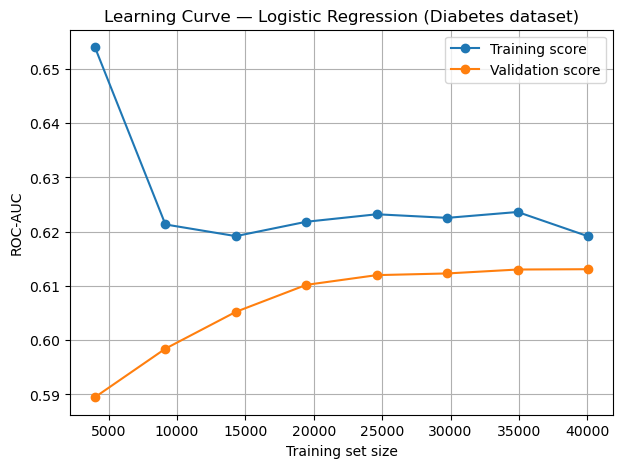

In [24]:
# learning curve
train_sizes2, train_scores2, val_scores2 = learning_curve(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced"),
    X2_train_s, y2_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=5,
    scoring="roc_auc",
    random_state=RANDOM_STATE
)

train_mean2 = train_scores2.mean(axis=1)
val_mean2 = val_scores2.mean(axis=1)

plt.figure(figsize=(7, 5))
plt.plot(train_sizes2, train_mean2, "o-", label="Training score")
plt.plot(train_sizes2, val_mean2, "o-", label="Validation score")
plt.xlabel("Training set size")
plt.ylabel("ROC-AUC")
plt.title("Learning Curve — Logistic Regression (Diabetes dataset)")
plt.legend()
plt.grid(True)
plt.show()

In [26]:
# including a fairness check for gender
metric_frame_gender = MetricFrame(
    metrics={"recall": recall_score, "selection_rate": selection_rate},
    y_true=y2_test, y_pred=pred_lr2,
    sensitive_features=rg_test["gender"]
)
print("Fairlearn metrics by gender, Diabetes dataset:")
print(metric_frame_gender.by_group)
print(f"Recall difference (max - min): {metric_frame_gender.difference()['recall']:.3f}")

Fairlearn metrics by gender, Diabetes dataset:
          recall  selection_rate
gender                          
Female  0.542274        0.379762
Male    0.530850        0.364862
Recall difference (max - min): 0.011


In [28]:
# including a fairness check for race
metric_frame_race2 = MetricFrame(
    metrics={"recall": recall_score, "selection_rate": selection_rate},
    y_true=y2_test, y_pred=pred_lr2,
    sensitive_features=rg_test["race"]
)
print("Fairlearn metrics by race, Diabetes dataset:")
print(metric_frame_race2.by_group)
print(f"Recall difference (max - min): {metric_frame_race2.difference()['recall']:.3f}")

Fairlearn metrics by race, Diabetes dataset:
                   recall  selection_rate
race                                     
AfricanAmerican  0.522659        0.352759
Asian            0.416667        0.285714
Caucasian        0.552177        0.387760
Hispanic         0.500000        0.263158
Other            0.363636        0.298387
Recall difference (max - min): 0.189


In [29]:
# top coeffiecent 
coef_diab = pd.Series(lr2.coef_[0], index=X2.columns).abs().sort_values(ascending=False)
print("Top 10 coefficients for Logistic Regression, Diabetes dataset")
coef_diab.head(10)

Top 10 coefficients for Logistic Regression, Diabetes dataset


number_inpatient            0.229937
discharge_disposition_id    0.153227
diabetesMed                 0.120720
age                         0.116311
time_in_hospital            0.107896
tolazamide                  0.105087
tolbutamide                 0.089798
chlorpropamide              0.061705
number_diagnoses            0.059195
number_emergency            0.053312
dtype: float64

## Summary

Two datasets (Adult Census Income, Diabetes 130-US Hospitals) were evaluated using Logistic Regression and SVM, extended with 5-fold cross-validation, learning curves, and a Fairlearn-based fairness audit.

**Cross-validation:** Both datasets showed low variance across folds (Adult: ROC-AUC 0.852 ± 0.006; Diabetes: 0.611 ± 0.006), confirming the original single-split results were stable and not a fluke of one particular data partition.

**Learning curves:** The Adult model converges smoothly and benefits from its full dataset size. The Diabetes model plateaus almost immediately, indicating its limitation is weak feature signal, not insufficient data.

**Fairness (Fairlearn):** Both datasets show meaningful recall disparities across race, and the Adult dataset also shows a large disparity by sex (Female recall 0.194 vs Male 0.497). These gaps likely reflect bias already present in the historical data, not something introduced by the models themselves.

**Overall:** The evaluation methodology itself was sound and stable, but the underlying data carries real fairness risks. Neither model should be deployed in a high-stakes setting without bias mitigation and human oversight.